#### **Notebook Session 5 - GBM**

**Data:** url [ionosphere dataset](https://www.kaggle.com/datasets/jamieleech/ionosphere)

**GBM Gradient Boosting Machines**

Example with GBM comparing its efficiency with Decision Trees


In [1]:
%matplotlib inline
import warnings

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, cross_validate, validation_curve, train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, roc_auc_score, accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay, f1_score)
from sklearn.model_selection import learning_curve

In [2]:
columns = [f'feature_{str(i)}' for i in range(1, 35)] + ['class']

df = pd.read_csv("./data/ionosphere.csv", sep=",", names=columns)

# NaN diagnostics (instead of blind dropna)
nan_counts = df.isnull().sum()
total_nans = nan_counts.sum()
if total_nans == 0:
    print("No missing values found in the dataset.")
else:
    print(f"Total missing values: {total_nans}")
    print(nan_counts[nan_counts > 0])

df.head()

No missing values found in the dataset.


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,class
0,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,g
1,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
2,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
3,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,b
4,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g


* **Dataset Information**
* This radar data was collected by a system in Goose Bay, Labrador. This system consists of a phased array of 16 high-frequency antennas with a total transmitted power on the order of 6.4 kilowatts. See the paper for more details. The targets were free electrons in the ionosphere. "Good" radar returns are those showing evidence of some type of structure in the ionosphere. "Bad" returns are those that do not; their signals pass through the ionosphere.

* Received signals were processed using an autocorrelation function whose arguments are the time of a pulse and the pulse number. There were 17 pulse numbers for the Goose Bay system. Instances in this databse are described by 2 attributes per pulse number, corresponding to the complex values returned by the function resulting from the complex electromagnetic signal.

* All 34 are continuous. The 35th attribute is either "good" or "bad" according to the definition summarized above. This is a binary classification task.

In [3]:
# converting from string to numeric
df["class"]=df["class"].map({"g":1,"b":0})

In [4]:
y = df["class"]  # dependent (target) variable
X = df.drop(["class"], axis=1)  # independent variables

# Robust imputation (handles NaNs if present in new data)
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Diagnostics
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Class distribution:\n{y.value_counts().rename({1: 'good (1)', 0: 'bad (0)'})}")
constant_cols = [c for c in X.columns if X[c].nunique() <= 1]
if constant_cols:
    print(f"Constant features (consider removing): {constant_cols}")
else:
    print("No constant features found.")

X shape: (351, 34), y shape: (351,)
Class distribution:
class
good (1)    225
bad (0)     126
Name: count, dtype: int64
Constant features (consider removing): ['feature_2']


In [5]:
# Hold-out split for DT vs GBM comparison later
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

Train set: 280 samples, Test set: 71 samples


In [6]:
# create GBM model
gbm_model = GradientBoostingClassifier(n_iter_no_change=5,
                                       validation_fraction=0.20,
                                       random_state=17).fit(X,y)

In [7]:
cv_results = cross_validate(gbm_model, X, y, cv=10, scoring=["f1"],
                            return_train_score=True)

print("train f1 score:",cv_results['train_f1'].mean())
print("test f1 score:",cv_results['test_f1'].mean())

# using f1 score for evaluation metric because we have imbalanced dataset
#The gbm classifier model we created gives very good results in both train and test set

train f1 score: 0.9829145147287344
test f1 score: 0.9406253424196468


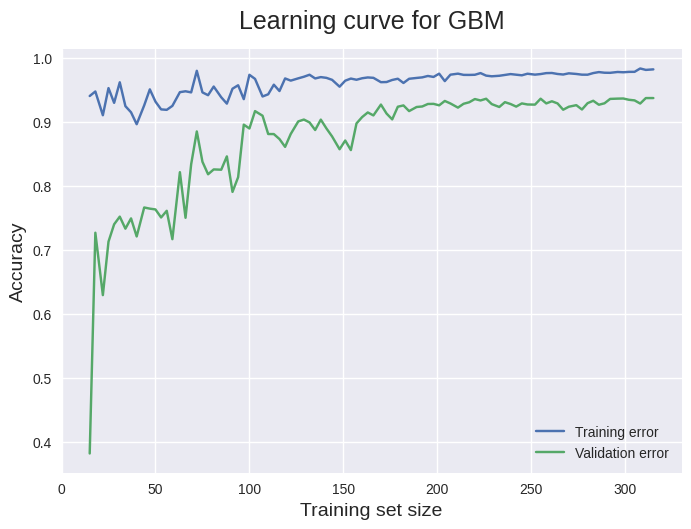

In [8]:
train_sizes, train_scores, test_scores = learning_curve(gbm_model, X, y, cv=10,
                                                        scoring='f1', n_jobs=-1, 
                                                        train_sizes=np.linspace(0.01, 1.0, 100))

train_mean = np.mean(train_scores, axis=1)
validation_mean = np.mean(test_scores, axis=1)

plt.style.use('seaborn-v0_8') # or 'seaborn-v0_8-whitegrid'
plt.plot(train_sizes, train_mean, label = 'Training error')
plt.plot(train_sizes, validation_mean, label = 'Validation error')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curve for GBM', fontsize = 18, y = 1.03)
plt.legend();

In [9]:
def val_curve_params(model, X, y, param_name, param_range, scoring="roc_auc", cv=10):
    train_score, test_score = validation_curve(
        model, X=X, y=y, param_name=param_name, param_range=param_range, scoring=scoring, cv=cv)

    mean_train_score = np.mean(train_score, axis=1)
    mean_test_score = np.mean(test_score, axis=1)

    plt.plot(param_range, mean_train_score,
             label="Training Score", color='b')

    plt.plot(param_range, mean_test_score,
             label="Validation Score", color='g')

    plt.title(f"Validation Curve for {type(model).__name__}")
    plt.xlabel(f"Number of {param_name}")
    plt.ylabel(f"{scoring}")
    plt.tight_layout()
    plt.legend(loc='best')
    plt.show(block=True)

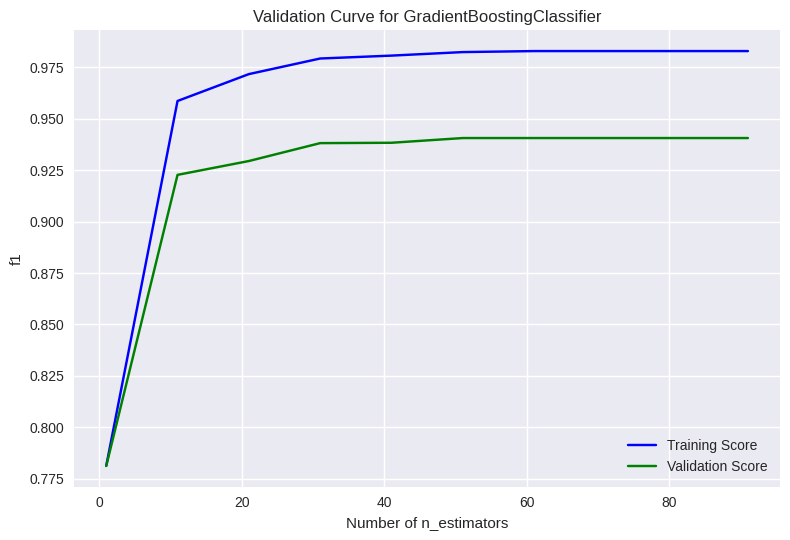

In [10]:
val_curve_params(gbm_model, X, y, "n_estimators", range(1,101,10), scoring="f1")

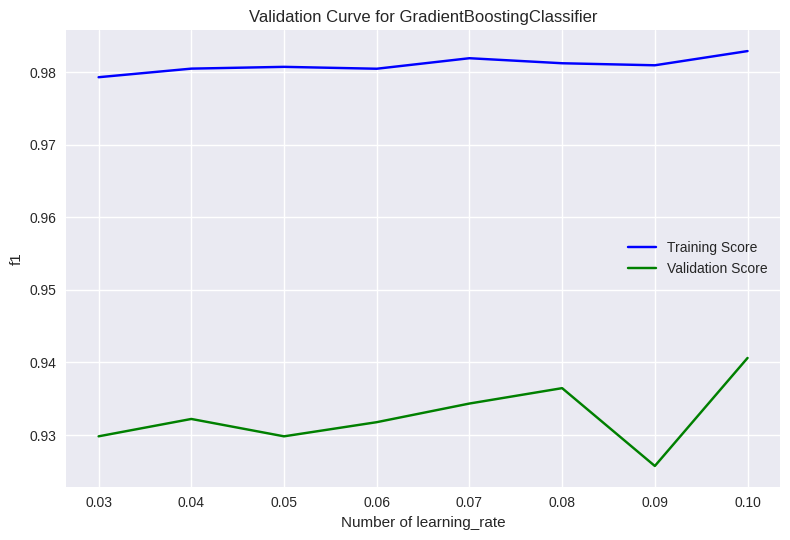

In [11]:
val_curve_params(gbm_model, X, y, "learning_rate", np.arange(0.03,0.1,0.01), scoring="f1")

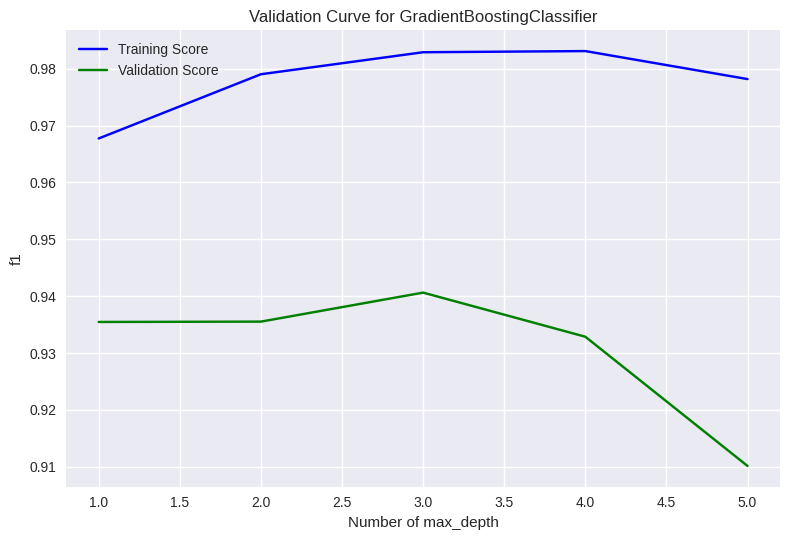

In [12]:
val_curve_params(gbm_model, X, y, "max_depth", range(1,6), scoring="f1")

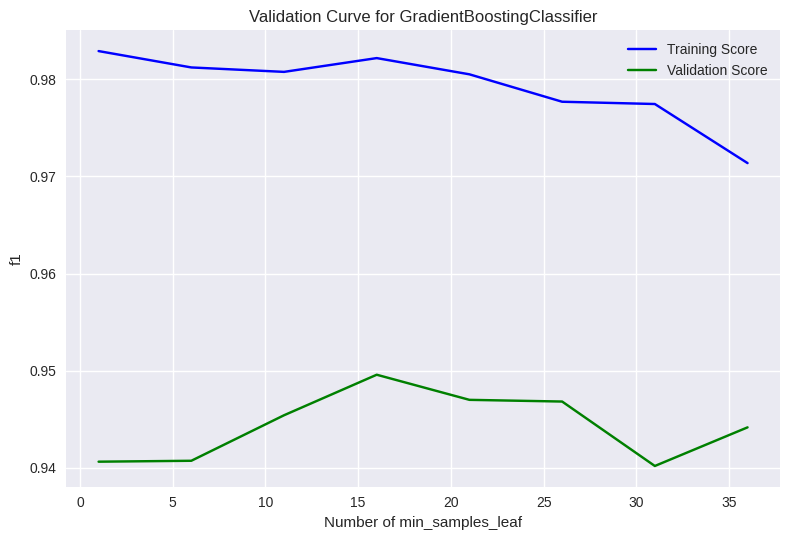

In [13]:
val_curve_params(gbm_model, X, y, "min_samples_leaf", range(1,41,5), scoring="f1")

In [14]:
gbm_params = {"learning_rate": [0.07,0.08],
              "max_depth": [1,2,3],
              "n_estimators": [10,20,30,40,50],
              "subsample": [0.5,0.6],
              "min_samples_split": range(12,16),
              "min_samples_leaf" : range(14,19),
              "max_features":[7,10,13]
             }

gbm_best_grid = GridSearchCV(gbm_model, gbm_params, cv=5, n_jobs=-1, verbose=True).fit(X, y)

Fitting 5 folds for each of 3600 candidates, totalling 18000 fits


In [15]:
gbm_best_grid.best_params_

{'learning_rate': 0.08,
 'max_depth': 3,
 'max_features': 13,
 'min_samples_leaf': 18,
 'min_samples_split': 12,
 'n_estimators': 50,
 'subsample': 0.6}

In [16]:
gbm_best_grid.best_score_

np.float64(0.9345674044265593)

In [17]:
gbm_final = gbm_model.set_params(**gbm_best_grid.best_params_,
                                 random_state=17, ).fit(X, y)
# create final model with best gridsearch hyperparameters

In [18]:
cv_results_final = cross_validate(gbm_final, X, y, cv=10, 
                            scoring=["f1"],
                            return_train_score=True)
print("train f1 score:",cv_results_final['train_f1'].mean())
print("test f1 score:",cv_results_final['test_f1'].mean())

train f1 score: 0.9721391513320518
test f1 score: 0.9489728426060526


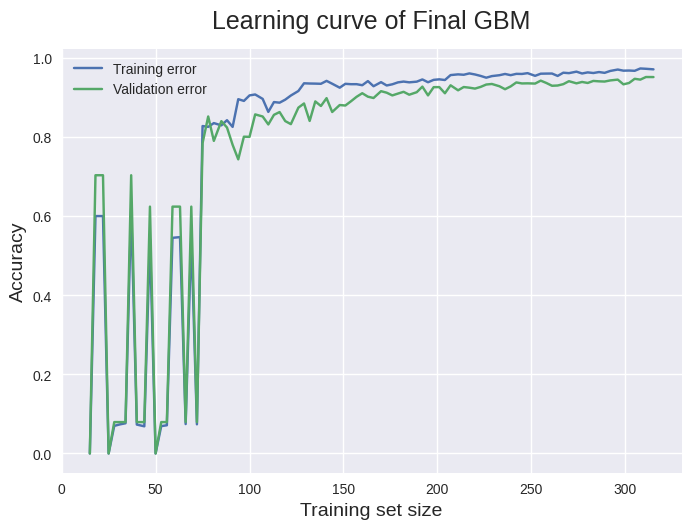

In [19]:
train_sizes_final, train_scores_final, test_scores_final = learning_curve(gbm_final, X, y,
                                                                          cv=10,
                                                        scoring='f1',n_jobs=-1, 
                                                        train_sizes=np.linspace(0.01, 1.0, 100))

train_mean_final = np.mean(train_scores_final, axis=1)
validation_mean_final = np.mean(test_scores_final, axis=1)

plt.style.use('seaborn-v0_8') # or 'seaborn-v0_8-whitegrid'
plt.plot(train_sizes_final, train_mean_final, label = 'Training error')
plt.plot(train_sizes_final, validation_mean_final, label = 'Validation error')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curve of Final GBM', fontsize = 18, y = 1.03)
plt.legend();

* We analyzed the complexity of the model specific to the hyperparameters using a validation curve and observed where the f1 score increases and decreases according to the hyperparameters. As a result of these observations, we determined the intervals where the hyperparameters would give the best results and we performed the hyperparameter optimization with gridsearchcv.
* As a result of gridsearchcv, train score decreased slightly, while test score increased. This made our GBM model more resistant to overfitting.

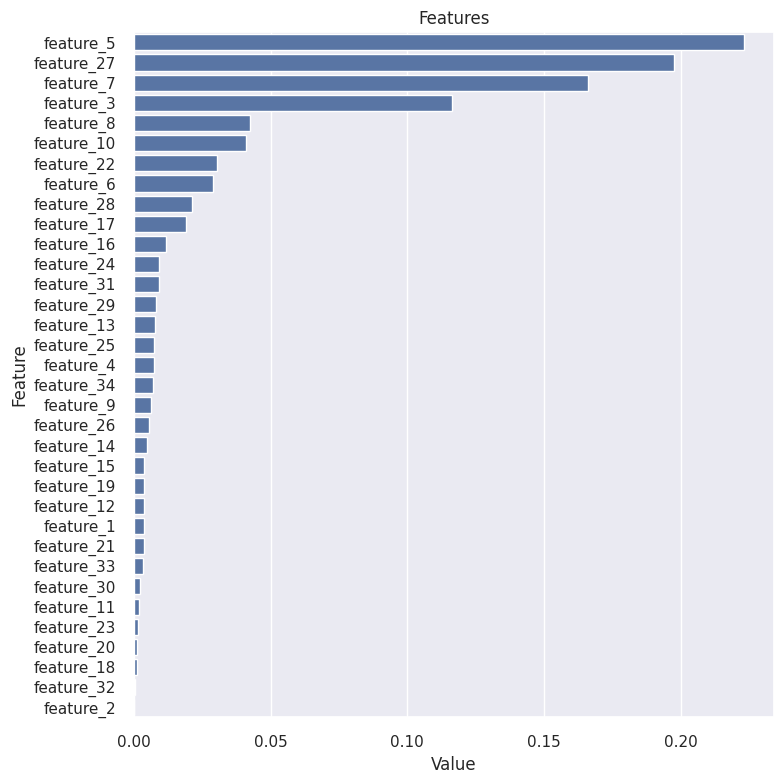

In [20]:
def plot_importance(model, features, num=len(X), save=False):
    feature_imp = pd.DataFrame({'Value': model.feature_importances_, 'Feature': features.columns})
    plt.figure(figsize=(8, 8))
    sns.set(font_scale=1)
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value",
                                                                     ascending=False)[0:num])
    plt.title('Features')
    plt.tight_layout()
    plt.show()
    if save:
        plt.savefig('importances.png')

plot_importance(gbm_final, X)

* When the feature importance graph is examined, the most important variables are; It is seen that a05,a27,a07,a03.Variables a32 and a02 have almost no effect on the model.

#### **Decision Tree Classifier**

We train a Decision Tree on the same dataset to serve as a baseline for comparison with the tuned GBM model.

In [21]:
# Train Decision Tree classifier
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")

Decision Tree Accuracy: 0.8873


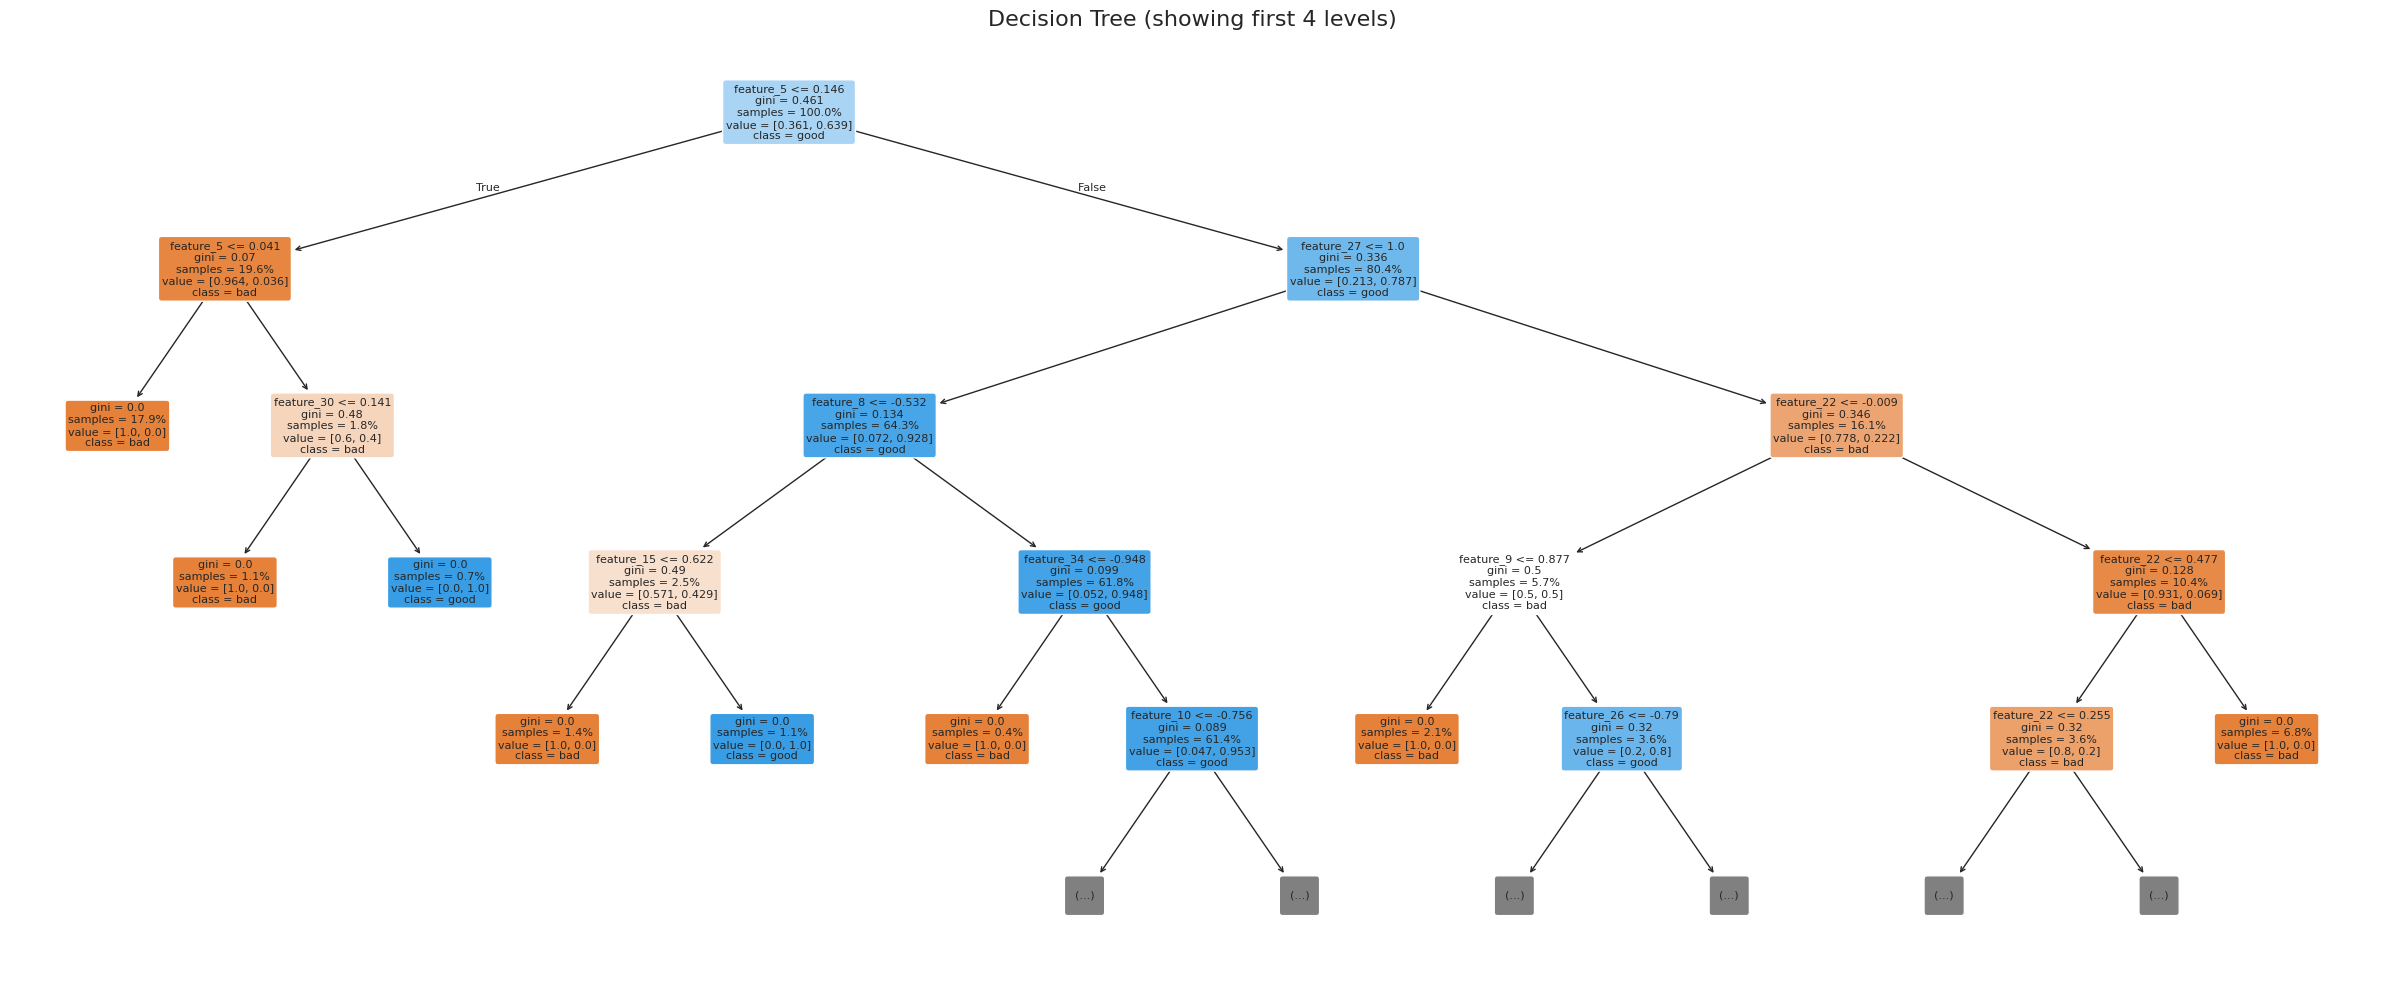

In [22]:
# Tree visualization (limited to depth=4 for readability)
plt.figure(figsize=(24, 10))
plot_tree(dt_model, max_depth=4, filled=True, rounded=True,
          feature_names=X.columns, class_names=['bad', 'good'],
          fontsize=8, proportion=True)
plt.title('Decision Tree (showing first 4 levels)', fontsize=16)
plt.tight_layout()
plt.show()

In [23]:
# Decision Tree classification report
print("Decision Tree - Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_dt, target_names=['bad', 'good']))

Decision Tree - Classification Report
              precision    recall  f1-score   support

         bad       0.81      0.88      0.85        25
        good       0.93      0.89      0.91        46

    accuracy                           0.89        71
   macro avg       0.87      0.89      0.88        71
weighted avg       0.89      0.89      0.89        71



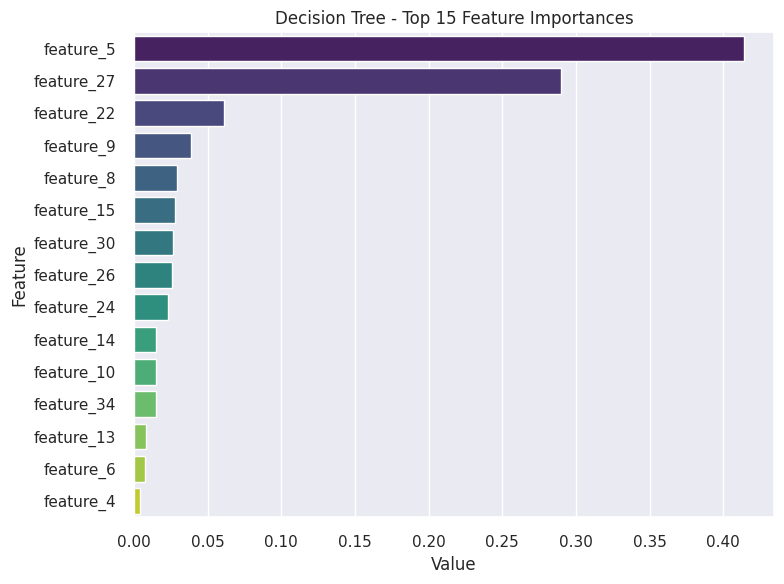

In [24]:
# Decision Tree feature importance (top 15)
dt_importance = pd.DataFrame({
    'Value': dt_model.feature_importances_,
    'Feature': X.columns
}).sort_values(by='Value', ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x='Value', y='Feature', data=dt_importance, palette='viridis')
plt.title('Decision Tree - Top 15 Feature Importances')
plt.tight_layout()
plt.show()

#### **Decision Tree vs GBM Comparison**

Side-by-side evaluation of both models on the held-out test set.

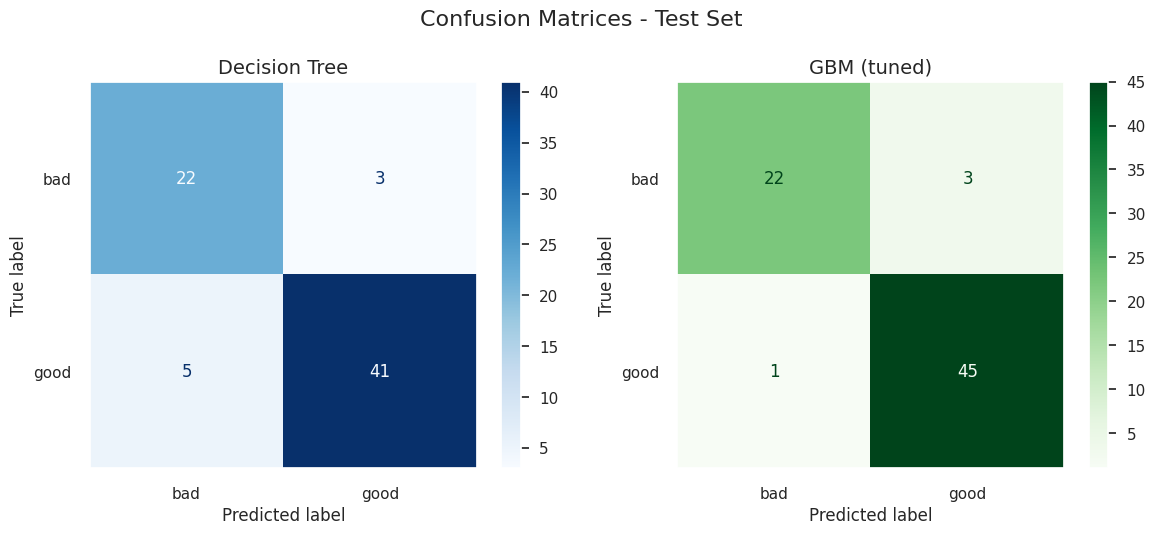

In [28]:
# Train GBM on the same hold-out split for fair comparison
gbm_final.fit(X_train, y_train)
y_pred_gbm = gbm_final.predict(X_test)

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt, display_labels=['bad', 'good'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Decision Tree', fontsize=14)
axes[0].grid(False)


ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gbm, display_labels=['bad', 'good'],
    cmap='Greens', ax=axes[1]
)
axes[1].set_title('GBM (tuned)', fontsize=14)
axes[1].grid(False)

plt.suptitle('Confusion Matrices - Test Set', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [26]:
# Classification reports
print("Decision Tree - Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_dt, target_names=['bad', 'good']))

print("\nGBM (tuned) - Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_gbm, target_names=['bad', 'good']))

# Summary comparison table
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score (weighted)', 'ROC AUC'],
    'Decision Tree': [
        accuracy_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_dt, average='weighted'),
        roc_auc_score(y_test, y_pred_dt)
    ],
    'GBM (tuned)': [
        accuracy_score(y_test, y_pred_gbm),
        f1_score(y_test, y_pred_gbm, average='weighted'),
        roc_auc_score(y_test, y_pred_gbm)
    ]
}).set_index('Metric')

comparison['Winner'] = comparison.apply(
    lambda row: 'GBM' if row['GBM (tuned)'] > row['Decision Tree'] else
                ('DT' if row['Decision Tree'] > row['GBM (tuned)'] else 'Tie'), axis=1)

print("\nModel Comparison Summary")
print("=" * 55)
comparison

Decision Tree - Classification Report
              precision    recall  f1-score   support

         bad       0.81      0.88      0.85        25
        good       0.93      0.89      0.91        46

    accuracy                           0.89        71
   macro avg       0.87      0.89      0.88        71
weighted avg       0.89      0.89      0.89        71


GBM (tuned) - Classification Report
              precision    recall  f1-score   support

         bad       0.96      0.88      0.92        25
        good       0.94      0.98      0.96        46

    accuracy                           0.94        71
   macro avg       0.95      0.93      0.94        71
weighted avg       0.94      0.94      0.94        71


Model Comparison Summary


,Decision Tree,GBM (tuned),Winner
Metric,,,
Accuracy,0.887324,0.943662,GBM
F1 Score (weighted),0.888239,0.943088,GBM
ROC AUC,0.885652,0.929130,GBM


### Comparison Interpretation

- **GBM** is an ensemble of shallow trees trained sequentially, where each tree corrects the errors of the previous ones. This typically leads to better generalization than a single Decision Tree.
- **Decision Tree** is a single tree that is prone to overfitting, especially on small datasets. However, it is more interpretable and faster to train.
- The confusion matrices above show how each model distributes its errors across the two classes (`bad` vs `good` radar returns).
- The summary table compares Accuracy, weighted F1 Score, and ROC AUC to give a comprehensive picture of performance.